In [ ]:
# as we have image size with 128*128 dimension that mean number of pixel will be around 128*128 = 16,384 pixels. While working with images
# each pixel will be treated as independent variable/feature. So total number of features will be 16,384.

In [176]:
from datasets import load_from_disk
import numpy as np
from sklearn.decomposition import  PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

In [116]:
dataset = load_from_disk("dataset")

In [117]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
    aug: Dataset({
        features: ['image', 'label'],
        num_rows: 4096
    })
    valid: Dataset({
        features: ['image', 'label'],
        num_rows: 1024
    })
})

In [118]:
train = dataset["train"]

In [119]:
train

Dataset({
    features: ['image', 'label'],
    num_rows: 4096
})

In [120]:
images = []

# looping through each data and appending image in images array
for data in train:
    img = data["image"]
    images.append(img)


In [121]:
# changing image value in numpy array
X_train = np.array(images,dtype=np.float32)

In [122]:
# each image is 128x128 size array which is 2D. so we need make 1D array 'cause linear regression expect 1D array
X_train.shape 

(4096, 128, 128)

In [124]:
X = X_train.reshape(X_train.shape[0],-1)
X.shape

(4096, 16384)

In [125]:
# normalizing the value that ranges from 0-255 to 0-1 
X = X/255.0

In [126]:
# So,features size will be number of pixel size so, next move to decrease the number of feature size using PCA(Principal Component Analysis).

In [161]:
# setting threshold value to 0.9 that means we calculate component that have 90% variance ratio.
X_pca = PCA(n_components=0.9)

In [162]:
# fitting our data to PCA
X_train_pca = X_pca.fit_transform(X)

In [164]:
X_train_pca
print("Components", len(X_pca.explained_variance_ratio_))
X_train_pca.shape

Components 372


(4096, 372)

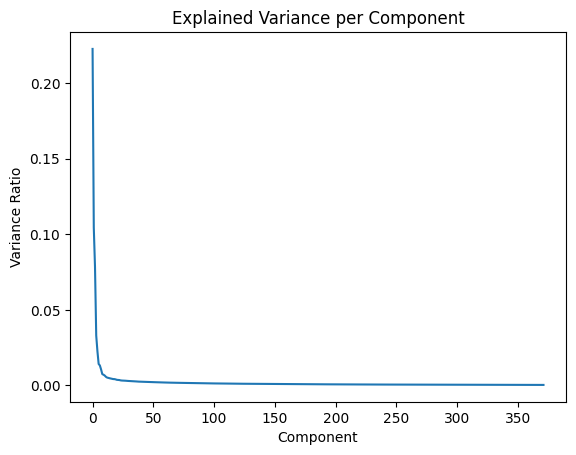

Total variance retained: 0.90012896


In [159]:
plt.plot(X_pca.explained_variance_ratio_)
plt.title("Explained Variance per Component")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

print("Total variance retained:", np.sum(X_pca.explained_variance_ratio_))



In [160]:
# Here we put a threshold to find number of component that preserve our most of variance, threshold was 90% where we 372 component.
# Though we decrease our feature size from 128*128 = 16384 to 372 we still have change of overfitting here.

In [166]:
# getting labels list
Y = []
for d in train:
    Y.append(d["label"])

In [169]:
len(Y)

4096

In [172]:
model = LogisticRegression(max_iter=1000)

In [174]:
X_train_val_pca = X_pca.transform(X)
model.fit(X_train_pca,Y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [175]:
pred_y = model.predict(X_train_val_pca)

In [177]:
print("Accuracy:", accuracy_score(Y, pred_y))
print(classification_report(Y, pred_y))

Accuracy: 0.87255859375
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       579
           1       1.00      1.00      1.00        43
           2       0.87      0.90      0.89      2044
           3       0.84      0.81      0.83      1430

    accuracy                           0.87      4096
   macro avg       0.91      0.91      0.91      4096
weighted avg       0.87      0.87      0.87      4096

